# Detecção de Fraude em Cartões de Crédito com Machine Learning e SHAP

Pipeline de ponta a ponta:
1. Carregamento de dados via URL e análise da proporção de fraudes (0,17%).
2. Pré-processamento com transformação logarítmica e separação estratificada.
3. Balanceamento exclusivo no treino (SMOTE e Undersampling).
4. Treinamento comparativo: Regressão Logística, Random Forest e XGBoost.
5. Otimização de limiares de decisão (Threshold Tuning) com foco em Recall e F1-Score.
6. Explicabilidade global e individual com SHAP (TreeExplainer).

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1. Carregamento dos dados diretamente da URL (sem arquivos locais)
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print("Dimensões do dataset:", df.shape)
contagem = df['Class'].value_counts()
print("\nDistribuição das classes:")
print(contagem)
print(f"Proporção de fraudes: {(contagem[1] / len(df)) * 100:.3f}%")

Dimensões do dataset: (284807, 31)

Distribuição das classes:
Class
0    284315
1       492
Name: count, dtype: int64
Proporção de fraudes: 0.173%


In [21]:
# 2. Engenharia de features
df['Amount_log'] = np.log1p(df['Amount'])
X = df.drop(columns=['Class', 'Time', 'Amount'])
y = df['Class']

# 3. Divisão Estratificada (80% treino / 20% teste) preservando os 0,17% no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Padronização (ajustada no treino e aplicada no teste)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Treino: {X_train_scaled.shape[0]} instâncias | Teste: {X_test_scaled.shape[0]} instâncias")
print(f"Fraudes reais no teste: {sum(y_test)} de {len(y_test)} transações")

Treino: 227845 instâncias | Teste: 56962 instâncias
Fraudes reais no teste: 98 de 56962 transações


In [22]:
# 5. Técnicas de amostragem restritas ao treino (sem data leakage)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

print(f"Treino com SMOTE: {X_train_smote.shape[0]} linhas (Fraudes: {sum(y_train_smote)})")
print(f"Treino com Undersampling: {X_train_under.shape[0]} linhas (Fraudes: {sum(y_train_under)})")

Treino com SMOTE: 454902 linhas (Fraudes: 227451)
Treino com Undersampling: 788 linhas (Fraudes: 394)


In [23]:
# Modelo 1: Regressão Logística (Baseline com SMOTE)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
y_probs_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Modelo 2: Random Forest (com Undersampling no treino)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_under, y_train_under)
y_probs_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Modelo 3: XGBoost (com penalização nativa de classes)
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)
xgb = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    random_state=42,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)
xgb.fit(X_train_scaled, y_train)
y_probs_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


In [24]:
def encontrar_melhor_threshold(y_true, y_probs, nome_modelo="Modelo"):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    melhor_idx = np.argmax(f1_scores)
    melhor_thresh = thresholds[melhor_idx]
    
    print(f"=== {nome_modelo} ===")
    print(f"Limiar Ótimo: {melhor_thresh:.4f}")
    print(f"F1-Score: {f1_scores[melhor_idx]:.4f} | Precisão: {precisions[melhor_idx]:.4f} | Recall: {recalls[melhor_idx]:.4f}\n")
    return melhor_thresh

thresh_lr = encontrar_melhor_threshold(y_test, y_probs_lr, "Regressão Logística")
thresh_rf = encontrar_melhor_threshold(y_test, y_probs_rf, "Random Forest")
thresh_xgb = encontrar_melhor_threshold(y_test, y_probs_xgb, "XGBoost")

=== Regressão Logística ===
Limiar Ótimo: 1.0000
F1-Score: 0.8272 | Precisão: 0.8495 | Recall: 0.8061

=== Random Forest ===
Limiar Ótimo: 0.9400
F1-Score: 0.7745 | Precisão: 0.7453 | Recall: 0.8061

=== XGBoost ===
Limiar Ótimo: 0.9966
F1-Score: 0.8202 | Precisão: 0.9125 | Recall: 0.7449



In [25]:
modelos_dict = {
    "Regressão Logística": (y_probs_lr, thresh_lr),
    "Random Forest": (y_probs_rf, thresh_rf),
    "XGBoost": (y_probs_xgb, thresh_xgb)
}

tabela = []
for nome, (probs, t_opt) in modelos_dict.items():
    # Padrão 0.50
    pred_05 = (probs >= 0.50).astype(int)
    r_05 = recall_score(y_test, pred_05, pos_label=1)
    p_05 = precision_score(y_test, pred_05, pos_label=1, zero_division=0)
    f_05 = f1_score(y_test, pred_05, pos_label=1)
    
    # Otimizado
    pred_opt = (probs >= t_opt).astype(int)
    r_opt = recall_score(y_test, pred_opt, pos_label=1)
    p_opt = precision_score(y_test, pred_opt, pos_label=1, zero_division=0)
    f_opt = f1_score(y_test, pred_opt, pos_label=1)
    
    tabela.append({
        "Modelo": nome,
        "Limiar Padrão": 0.50,
        "Recall (0.50)": f"{r_05:.2%}",
        "Precisão (0.50)": f"{p_05:.2%}",
        "F1 (0.50)": f"{f_05:.4f}",
        "Limiar Otimizado": f"{t_opt:.4f}",
        "Recall (Otimizado)": f"{r_opt:.2%}",
        "Precisão (Otimizada)": f"{p_opt:.2%}",
        "F1 (Otimizado)": f"{f_opt:.4f}"
    })

df_resultado = pd.DataFrame(tabela)
display(df_resultado)

,Modelo,Limiar Padrão,Recall (0.50),Precisão (0.50),F1 (0.50),Limiar Otimizado,Recall (Otimizado),Precisão (Otimizada),F1 (Otimizado)
0,Regressão Logística,0.5,91.84%,5.57%,0.1051,1.0000,80.61%,84.95%,0.8272
1,Random Forest,0.5,90.82%,4.80%,0.0912,0.9400,80.61%,74.53%,0.7745
2,XGBoost,0.5,84.69%,49.11%,0.6217,0.9966,74.49%,91.25%,0.8202


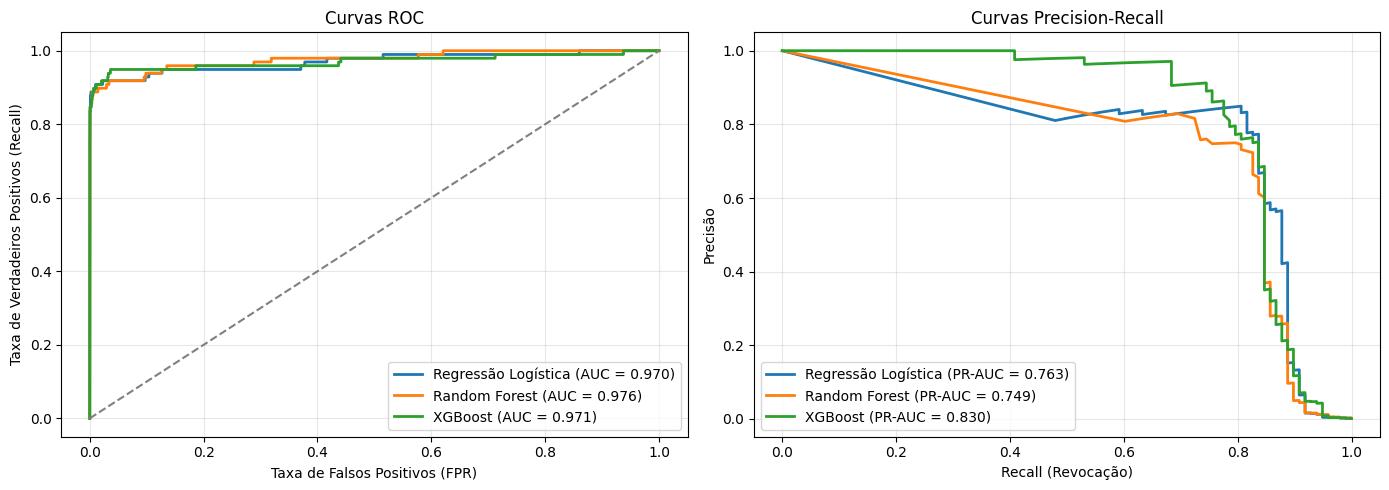

In [26]:
plt.figure(figsize=(14, 5))

# Curva ROC
plt.subplot(1, 2, 1)
for nome, (probs, _) in modelos_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f"{nome} (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (Recall)")
plt.title("Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Curva Precision-Recall
plt.subplot(1, 2, 2)
for nome, (probs, _) in modelos_dict.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    plt.plot(rec, prec, lw=2, label=f"{nome} (PR-AUC = {auc(rec, prec):.3f})")

plt.xlabel("Recall (Revocação)")
plt.ylabel("Precisão")
plt.title("Curvas Precision-Recall")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
y_pred_campeao = (y_probs_xgb >= thresh_xgb).astype(int)
print(f"Classification Report - XGBoost com Limiar {thresh_xgb:.4f}:\n")
print(classification_report(y_test, y_pred_campeao, target_names=["Legítima (0)", "Fraude (1)"]))

Classification Report - XGBoost com Limiar 0.9966:

              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.91      0.74      0.82        98

    accuracy                           1.00     56962
   macro avg       0.96      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



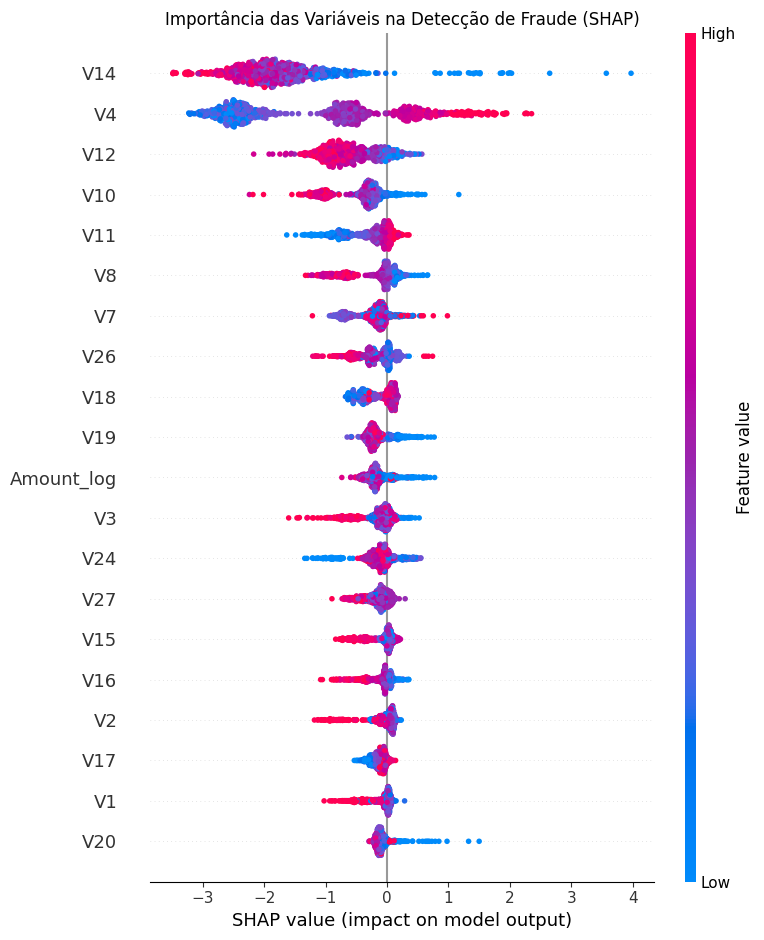

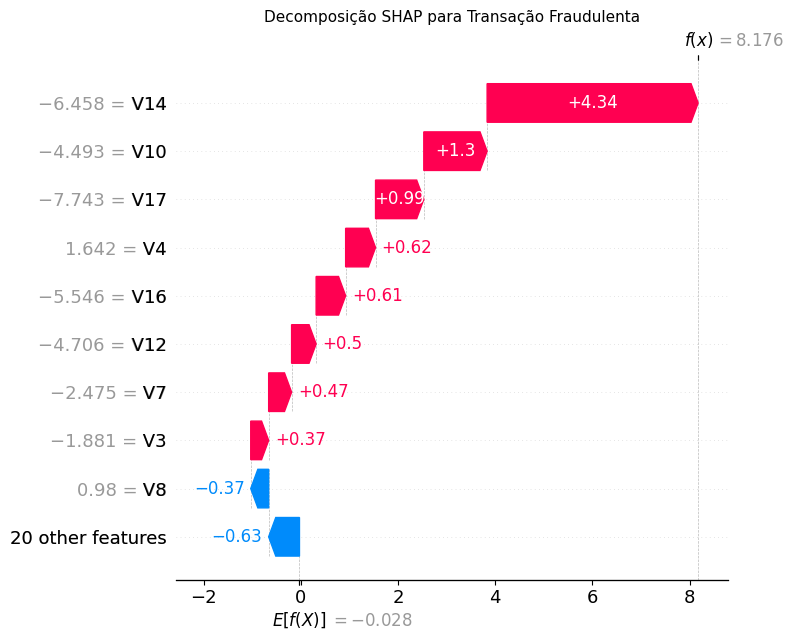

In [29]:
explainer = shap.TreeExplainer(xgb)

# 1. Amostra de 1000 transações de teste para cálculo ágil
X_sample = X_test_scaled.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Gráfico Global (Summary Plot)
plt.figure(figsize=(10, 6))
plt.title("Importância das Variáveis na Detecção de Fraude (SHAP)", fontsize=12)
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# 2. Gráfico Local (Explicando a primeira fraude encontrada no conjunto de teste)
# Localiza a posição inteira (0 a N) onde y_test == 1
pos_fraude = np.where(y_test.values == 1)[0][0]

# Calcula a explicação da instância de fraude correspondente
explanation = explainer(X_test_scaled.iloc[[pos_fraude]])

plt.figure(figsize=(10, 5))
shap.plots.waterfall(explanation[0], show=False)
plt.title("Decomposição SHAP para Transação Fraudulenta", fontsize=11)
plt.tight_layout()
plt.show()